In [26]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

In [4]:
# Download training data from open datasets.
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Download test data from open datasets.
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

100%|███████████████████████████| 26421880/26421880 [00:34<00:00, 775034.79it/s]


Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|█████████████████████████████████| 29515/29515 [00:00<00:00, 171288.11it/s]


Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



100%|█████████████████████████████| 4422102/4422102 [00:04<00:00, 910276.68it/s]


Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████████████████████████████| 5148/5148 [00:00<00:00, 4216418.08it/s]

Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw



In [9]:
batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break


Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


In [56]:
# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),   # Increased neurons
            nn.ReLU(),
            nn.Dropout(0.3),          # Dropout helps avoid overfitting

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, 64),
            nn.ReLU(),
            
            nn.Linear(64, 10)        # 10 classes (MNIST, etc.)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork()
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=64, bias=True)
    (6): ReLU()
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [57]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [58]:
train_losses = []
test_losses = []

In [59]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    total_loss = 0

    for batch, (X, y) in enumerate(dataloader):
        pred = model(X)
        loss = loss_fn(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        total_loss += loss.item()

        if batch % 100 == 0:
            loss_val, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss_val:>7f}  [{current:>5d}/{size:>5d}]")
    
    avg_loss = total_loss / len(dataloader)
    train_losses.append(avg_loss)

In [60]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    avg_test_loss = test_loss / num_batches
    accuracy = correct / size
    test_losses.append(avg_test_loss)

    print(f"Test Error: \n Accuracy: {(100*accuracy):>0.1f}%, Avg loss: {avg_test_loss:>8f} \n")


In [61]:
epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done!")


Epoch 1
-------------------------------
loss: 2.293055  [   64/60000]
loss: 0.720288  [ 6464/60000]
loss: 0.478271  [12864/60000]
loss: 0.568704  [19264/60000]
loss: 0.586947  [25664/60000]
loss: 0.511565  [32064/60000]
loss: 0.400852  [38464/60000]
loss: 0.502387  [44864/60000]
loss: 0.483681  [51264/60000]
loss: 0.513830  [57664/60000]
Test Error: 
 Accuracy: 83.4%, Avg loss: 0.445232 

Epoch 2
-------------------------------
loss: 0.320211  [   64/60000]
loss: 0.376554  [ 6464/60000]
loss: 0.333716  [12864/60000]
loss: 0.445299  [19264/60000]
loss: 0.404323  [25664/60000]
loss: 0.365184  [32064/60000]
loss: 0.344075  [38464/60000]
loss: 0.484459  [44864/60000]
loss: 0.478992  [51264/60000]
loss: 0.551741  [57664/60000]
Test Error: 
 Accuracy: 84.8%, Avg loss: 0.414861 

Epoch 3
-------------------------------
loss: 0.298427  [   64/60000]
loss: 0.379401  [ 6464/60000]
loss: 0.303979  [12864/60000]
loss: 0.421525  [19264/60000]
loss: 0.363202  [25664/60000]
loss: 0.360707  [32064/600

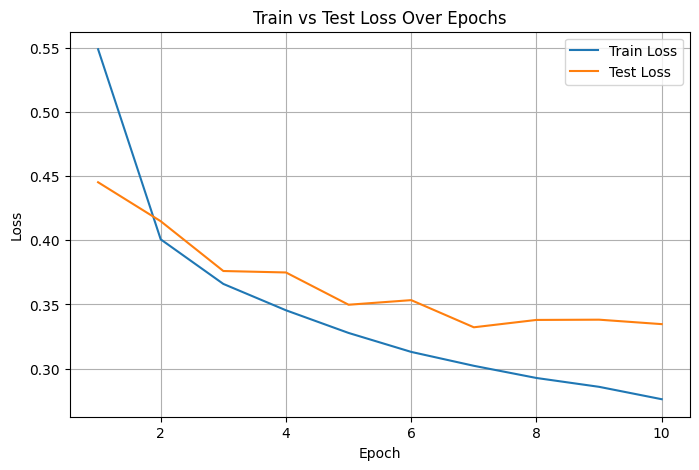

In [62]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), train_losses, label="Train Loss")
plt.plot(range(1, epochs+1), test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Test Loss Over Epochs")
plt.legend()
plt.grid(True)
plt.show()

#### The model is perfectly trained without overfitting and underfitting